In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json

from protest_impact.util import project_root

with open(project_root / "data" / "protest" / "predictions.jsonl") as f:
    predictions = [json.loads(line) for line in f]

with open(project_root / "data" / "news" / "protest_news_shuffled_v2.jsonl") as f:
    news = [json.loads(line) for line in f]

In [3]:
protest_news = []
for prediction, article in zip(predictions, news):
    if prediction["label"] == "LABEL_1":
        for k, v in article["meta"].items():
            article[k] = v
        del article["meta"]
        article["score"] = prediction["score"]
        protest_news.append(article)

In [4]:
len(protest_news)

20879

In [5]:
protest_news.sort(key=lambda x: x["score"], reverse=True)

In [6]:
%%capture
protest_news[:5]

In [7]:
%%capture
protest_news[-5:]

In [8]:
%%capture
protest_news[-505:-500]

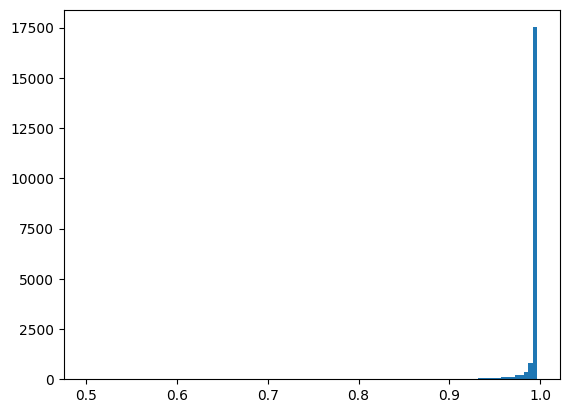

In [9]:
# plot distribution of scores
import matplotlib.pyplot as plt
import numpy as np

scores = [article["score"] for article in protest_news]
plt.hist(scores, bins=100)
plt.show()

In [10]:
with open(project_root / "data" / "protest" / "protest_news_predicted.jsonl", "w") as f:
    for article in protest_news:
        f.write(json.dumps(article) + "\n")

In [11]:
from protest_impact.data.protests.config import movement_keywords

topics = {}
for movement, keywords in movement_keywords.items():
    topics[movement] = []
    if "movement" in keywords:
        topics[movement] += keywords["movement"]
    if "topic" in keywords:
        topics[movement] += keywords["topic"]
    topics[movement] = [a.replace("*", "") for a in topics[movement]]

In [12]:
for article in protest_news:
    article["topics"] = []
    text = article["text"].lower()
    for movement, keywords in topics.items():
        for keyword in keywords:
            if keyword in text:
                article["topics"].append(movement)
                break

In [19]:
for article in protest_news:
    if len(article["topics"]) > 1:
        if "covid" in article["topics"]:
            article["topics"].remove("covid")
        elif "international" in article["topics"]:
            article["topics"].remove("international")

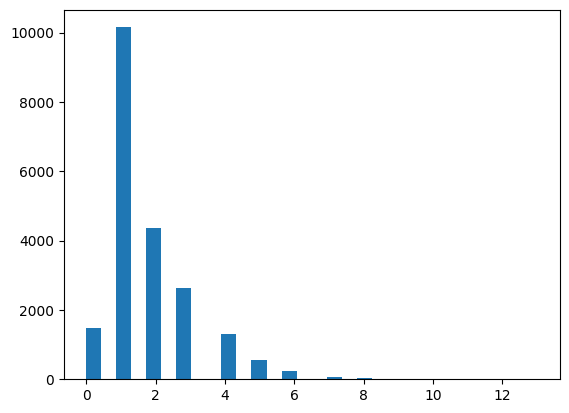

In [28]:
# plot distribution of number of topics per article
import matplotlib.pyplot as plt
import numpy as np

num_topics = [len(article["topics"]) for article in protest_news]
plt.hist(num_topics, bins=30)
plt.show()

In [21]:
from collections import Counter

Counter([str(sorted(a["topics"])) for a in protest_news]).most_common(50)

[("['international']", 2048),
 ("['labour']", 1932),
 ('[]', 1485),
 ("['covid']", 1351),
 ("['right wing']", 699),
 ("['racism']", 676),
 ("['climate']", 585),
 ("['feminism']", 501),
 ("['football']", 491),
 ("['yellow jackets']", 418),
 ("['football', 'labour']", 401),
 ("['anti-immigration']", 341),
 ("['anti capitalism']", 300),
 ("['labour', 'yellow jackets']", 269),
 ("['climate', 'environment']", 192),
 ("['labour', 'right wing']", 179),
 ("['anti-war']", 174),
 ("['labour', 'racism']", 144),
 ("['left wing']", 134),
 ("['football', 'right wing']", 130),
 ("['racism', 'right wing']", 129),
 ("['anti-immigration', 'right wing']", 129),
 ("['feminism', 'racism']", 122),
 ("['feminism', 'labour']", 113),
 ("['left wing', 'right wing']", 109),
 ("['football', 'racism']", 107),
 ("['refugees']", 107),
 ("['environment']", 97),
 ("['football', 'labour', 'yellow jackets']", 95),
 ("['feminism', 'football']", 79),
 ("['labour', 'refugees']", 74),
 ("['anti capitalism', 'right wing']", 

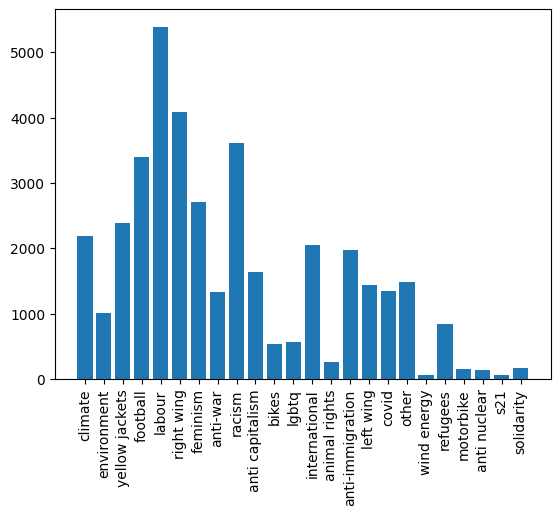

In [25]:
import matplotlib.pyplot as plt
import numpy as np

topics = [a["topics"] for a in protest_news]
topics = [["other"] if len(a) == 0 else a for a in topics]
topics = [item for sublist in topics for item in sublist]
topic_counts = Counter(topics)
plt.bar(topic_counts.keys(), topic_counts.values())
plt.xticks(rotation=90)
plt.show()

In [17]:
no_topic = [a for a in protest_news if len(a["topics"]) == 0]
len(no_topic)

1485

In [23]:
import random

random.seed(20230213)
random.shuffle(no_topic)
for article in no_topic[:3]:
    print(article["text"])

[Washington/Kapitol: Polizist stirbt im Krankenhaus - ein Trump-Demonstrant griff ihn wohl mit Feuerlöscher an]

## Ausschreitungen in Washington: Nach Trump-Rede Evakuation des Kapitols

Update vom 6. Januar, 20.29 Uhr: Die Sitzung zur Zertifizierung der Wahlergebnisse im Kapitol musste unterbrochen werden. Anhängern des abgewählten Präsidenten Donald Trump ist es wohl gelungen, das Gebäude zu stürmen, wie US-amerikanische Medien berichten. Einige Teilnehmer der Sitzung von Senat und Repräsentantenhaus seien evakuiert worden, heißt es übereinstimmend. Darunter ist auch Vizepräsident Mike Pence.

Verschiedene Beiträge in sozialen Medien zeigen, wie weit die Unterstützer von Trump ins Gebäude vorgedrungen sind. Sie sind nur wenige Meter vom Eingang zum Sitzungssaal entfernt. Andere sollen noch vor dem Gebäude auf Stufen und Terrassen steigen, um sich Zutritt zu verschaffen. Laut CNN haben die Einsatzkräfte Verstärkung angefordert, um der Situation Herr zu werden.
[Bei Demo von "Eltern-s

In [29]:
with open(project_root / "data" / "protest" / "protest_news_predicted.jsonl", "w") as f:
    for article in protest_news:
        f.write(json.dumps(article) + "\n")